### Imports

In [1]:
import nevergrad as ng
import numpy as np
from matplotlib import pyplot as plt
np.set_printoptions(legacy='1.25')

Basic objective function

In [2]:
def f(x):
    return sum((x - 3) ** 2)

Default nevergrad optimizer

In [3]:
optimizer = ng.optimizers.NgIoh(parametrization=2, budget=30)

Get the best recommendation

In [4]:
recommendation = optimizer.minimize(f)
recommendation.value

array([3., 3.])

### Parameterization

What if we want an array of variables to optimize?

In [5]:
def f(x):
    return x[0] - x[1] + x[2]**2 - x[3]**3

In [6]:
param = ng.p.Array(shape = (4,))

In [7]:
optimizer = ng.optimizers.NgIoh(parametrization=param, budget=30)
recommendation = optimizer.minimize(f)
recommendation.value

array([ 2878.89849046,  2189.43227077, -1217.16513671,  8590.0346321 ])

What if we want to set bounds on our variables?

In [8]:
param = ng.p.Array(shape = (4,)).set_bounds(0, 100)

In [9]:
optimizer = ng.optimizers.NgIoh(parametrization=param, budget=30)
recommendation = optimizer.minimize(f)
recommendation.value

/mnt/G/Rnd/Coding_Stuff/MSML610/umd_classes/class_project/MSML610/Fall2025/Projects/UmdTask61_Fall2025_nevergrad_Multi_Objective_Optimization_for_Portfolio_Management/.venv/lib/python3.12/site-packages/scipy/_lib/pyprima/common/preproc.py:202: UserWarning: COBYLA: Invalid RHOEND; it should be a positive number and RHOEND <= RHOBEG; it is set to 1e-06
  warn(f'{solver}: Invalid RHOEND; it should be a positive number and RHOEND <= RHOBEG; it is set to {rhoend}')


array([10.03950597,  9.98281244, 42.15731057, 98.95742374])

## Multi-objective Minimization

Instead of optimizing one objective, we might have multiple objectives that can conflict.

In [10]:
def f(x):
    return [np.sum(x**2), np.sum((x - 2)**2)]

In [11]:
optimizer = ng.optimizers.NgIoh(parametrization=2, budget=1000)
recommendation = optimizer.minimize(f)

/mnt/G/Rnd/Coding_Stuff/MSML610/umd_classes/class_project/MSML610/Fall2025/Projects/UmdTask61_Fall2025_nevergrad_Multi_Objective_Optimization_for_Portfolio_Management/.venv/lib/python3.12/site-packages/nevergrad/optimization/base.py:149: BadLossWarning: Updating fitness with inf value
  warnings.warn(msg, e)
/mnt/G/Rnd/Coding_Stuff/MSML610/umd_classes/class_project/MSML610/Fall2025/Projects/UmdTask61_Fall2025_nevergrad_Multi_Objective_Optimization_for_Portfolio_Management/.venv/lib/python3.12/site-packages/nevergrad/optimization/base.py:149: LossTooLargeWarning: Clipping very high value inf in tell (rescale the cost function?).
  warnings.warn(msg, e)


A pareto front is the set of all pareto efficient solutions.

In [12]:
ff = optimizer.pareto_front()
ff

[Array{(2,)}:[0. 0.],
 Array{(2,)}:[0.75366994 0.75834438],
 Array{(2,)}:[0.11717341 0.15321834],
 Array{(2,)}:[0.38498639 0.31037753],
 Array{(2,)}:[0.33102204 0.5038576 ],
 Array{(2,)}:[0.27902735 0.49974068],
 Array{(2,)}:[0.26108726 0.31281144],
 Array{(2,)}:[0.59278741 0.45910036],
 Array{(2,)}:[0.95050656 1.01515432],
 Array{(2,)}:[0.72219103 0.66393815],
 Array{(2,)}:[0.70481435 0.67187931],
 Array{(2,)}:[0.83859989 0.61965063],
 Array{(2,)}:[0.59278741 0.66179347],
 Array{(2,)}:[1.07242846 1.01515432],
 Array{(2,)}:[1.11864611 1.25426484],
 Array{(2,)}:[0.12266624 0.31281144],
 Array{(2,)}:[0.32500242 0.19120047],
 Array{(2,)}:[0.16353973 0.30350379],
 Array{(2,)}:[0.58651163 0.52141429],
 Array{(2,)}:[1.13318158 1.1639609 ],
 Array{(2,)}:[0.98744213 0.79115889],
 Array{(2,)}:[0.59413149 0.60590147],
 Array{(2,)}:[0.9814603  0.89922601],
 Array{(2,)}:[0.58651163 0.61187576],
 Array{(2,)}:[0.73946314 0.74360786],
 Array{(2,)}:[0.90178259 0.91415736],
 Array{(2,)}:[0.68078049 0.6

In this case, each of these solutions optimizes the array in such a way that any further mutations would require increases in the loss of another objective function.

We can plot this out to get a visual understanding of what the frontier looks like.

In [13]:
pts = [(x.value[0], x.value[1]) for x in ff]
pts_x = [x for (x, _) in pts]
pts_y = [y for (_, y) in pts]

In [14]:
x = np.linspace(0, 2, 100)
y = np.linspace(0, 2, 100)
X, Y = np.meshgrid(x, y)
F1 = X**2 + Y**2
F2 = (X - 2)**2 + (Y - 2)**2

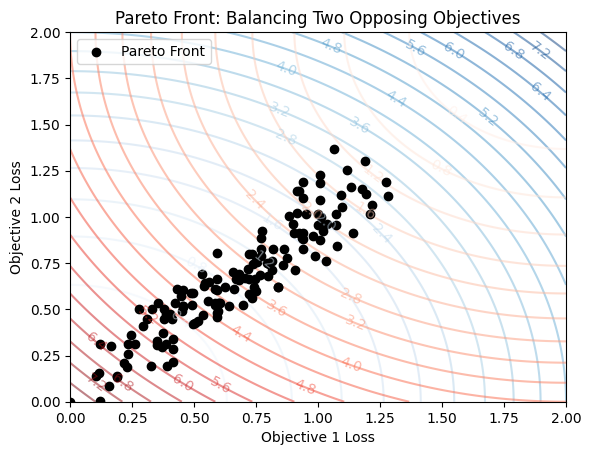

In [15]:
fig = plt.subplots()
cs1 = plt.contour(X, Y, F1, levels=20, cmap='Blues', alpha=0.5)
cs2 = plt.contour(X, Y, F2, levels=20, cmap='Reds', alpha=0.5)
plt.clabel(cs1, inline=False)
plt.clabel(cs2, inline=False)
plt.scatter(pts_x, pts_y, c="black", label="Pareto Front", zorder=3)
plt.legend()
plt.title("Pareto Front: Balancing Two Opposing Objectives")
plt.xlabel("Objective 1 Loss")
plt.ylabel("Objective 2 Loss")
plt.show()

The pareto optimal front in this case looks roughly like a straight line. In most cases, this is a lot harder to visualize due to the number of dimensions scaling with objectives. Now that we have a way of calculating a frontier, we can apply this concept straight to our financial models.

## API Usage with our classes

In [ ]:
from classes import Stock, Portfolio, PortfolioOptimizer
from portfolio_utils import *
import random
import seaborn as sns

We provide 3 classes for use with this API. The first two are simply abstractions on top of financial data.

Stock contains a ticker and a name

In [17]:
stocks = [Stock("AAPL", "Apple"), Stock("MSFT", "Microsoft"), Stock("AMZN", "Amazon"), Stock("NVDA", "Nvidia"), Stock("GOOG", "Alphabet")]

A portfolio consists of a list of stocks and their respective weights

In [18]:
weights = [0.2] * len(stocks)
portfolio = Portfolio(stocks, weights)

To apply a nevergrad optimizer over our portfolio, we require a thin wrapper layer that provides an optimize function.

Utils contains a few objective functions that might be useful for a general user, but there are no restrictions on which objective to use for the portfolio.

In [19]:
class RiskMinimizer(PortfolioOptimizer):

	def optimize(self, returns, covar, tickers):
		def objective(weights):
			return minimize_risk(weights, covar)

		optimizer = ng.optimizers.NgIoh(parametrization=ng.p.Array(init=[1.0/len(tickers)] * len(tickers), lower = 0, upper = 1, mutable_sigma=True), budget=1000)
		rec = optimizer.minimize(objective)
		return rec

In [20]:
r = RiskMinimizer()

Optimize requires expected returns, covariance, and the tickers themselves.

In this case, we set a larger interval (1 month) to get expected returns of a longer period.

In [21]:
prices = fetch_prices(portfolio.stocks, "2022-01-01", "2024-12-31", interval="1mo")
rets = returns(prices, "arith")
cov = rets.cov() 	# Covariance of returns
tickers = [s.ticker for s in portfolio.stocks]

/mnt/G/Rnd/Coding_Stuff/MSML610/umd_classes/class_project/MSML610/Fall2025/Projects/UmdTask61_Fall2025_nevergrad_Multi_Objective_Optimization_for_Portfolio_Management/utils.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(


In [22]:
rec = r.optimize(rets, cov, tickers)

/mnt/G/Rnd/Coding_Stuff/MSML610/umd_classes/class_project/MSML610/Fall2025/Projects/UmdTask61_Fall2025_nevergrad_Multi_Objective_Optimization_for_Portfolio_Management/.venv/lib/python3.12/site-packages/scipy/_lib/pyprima/common/preproc.py:202: UserWarning: COBYLA: Invalid RHOEND; it should be a positive number and RHOEND <= RHOBEG; it is set to 1e-06
  warn(f'{solver}: Invalid RHOEND; it should be a positive number and RHOEND <= RHOBEG; it is set to {rhoend}')


In [23]:
list(rec.value)

[0.40991198471709644,
 2.891077098402898e-05,
 0.20503241170264874,
 0.3832342611086797,
 0.002307678872840742]

In [24]:
portfolio.weights = rec.value

In [25]:
ex_rets = expected_return(rets)
ex_portfolio_ret = portfolio_return(portfolio.weights, ex_rets)
ex_portfolio_ret

/mnt/G/Rnd/Coding_Stuff/MSML610/umd_classes/class_project/MSML610/Fall2025/Projects/UmdTask61_Fall2025_nevergrad_Multi_Objective_Optimization_for_Portfolio_Management/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


0.0005687248084894523

Pretty small returns because we optimized for risk

In [26]:
portfolio_variance(portfolio.weights, cov)

0.00025281308995547103

Very low variance in this portfolio.

In [27]:
sharpe(ex_portfolio_ret, portfolio_variance(portfolio.weights, cov))

-1.2220853109299106

Negative sharpe ratio suggests that this portfolio doesn't generate enough return for the risk. Basically, it'd be better to just put our money in a Treasury since that would generate higher returns and have lower risk.

In [28]:
class MultiOptimizer(PortfolioOptimizer):

	def optimize(self, returns, covar, tickers):
		def objective(weights):
			return multiobjective(weights, returns, covar)

		init_weights = [1.0/len(tickers)] * len(tickers)

		optimizer = ng.optimizers.NgIoh(parametrization=ng.p.Array(init=init_weights, lower = 0, upper = 1, mutable_sigma=True), budget=100000)
		optimizer.minimize(objective)
		return optimizer

In [29]:
m = MultiOptimizer()

In [30]:
optimizer = m.optimize(rets.values, cov, tickers)

/mnt/G/Rnd/Coding_Stuff/MSML610/umd_classes/class_project/MSML610/Fall2025/Projects/UmdTask61_Fall2025_nevergrad_Multi_Objective_Optimization_for_Portfolio_Management/.venv/lib/python3.12/site-packages/nevergrad/optimization/base.py:149: BadLossWarning: Updating fitness with inf value
  warnings.warn(msg, e)
/mnt/G/Rnd/Coding_Stuff/MSML610/umd_classes/class_project/MSML610/Fall2025/Projects/UmdTask61_Fall2025_nevergrad_Multi_Objective_Optimization_for_Portfolio_Management/.venv/lib/python3.12/site-packages/nevergrad/optimization/base.py:149: LossTooLargeWarning: Clipping very high value inf in tell (rescale the cost function?).
  warnings.warn(msg, e)


In [31]:
pf = optimizer.pareto_front()
pts = [(x.value[0], x.value[1]) for x in pf]
pts_x = [x for (x, _) in pts]
pts_y = [y for (_, y) in pts]

Since we only have two objectives, we can again plot our frontier and see how it looks.

In [32]:
x = []
y = []
z = []
for i in range(100000):
    w = np.array([random.random() for _ in range(5)])
    w /= w.sum()
    ret = portfolio_return(w, rets.values)
    var = portfolio_variance(w, cov)
    loss = sum(multiobjective(w, ret, cov))
    x.append(ret)
    y.append(np.sqrt(var))
    z.append(loss)

df = pd.DataFrame(data = None)
df["Return"] = x
df["Std"] = y
df["Loss"] = z

In [33]:
pf_x = []
pf_y = []
pf_z = []
for i in pf:
    weights = np.array(i.value)
    weights /= weights.sum()
    ret = portfolio_return(weights, rets.values)
    var = portfolio_variance(weights, cov)
    loss = sum(multiobjective(weights, ret, cov))
    pf_x.append(ret)
    pf_y.append(np.sqrt(var))
    pf_z.append(loss)
    
pf_data = pd.DataFrame(data=None)
pf_data["Return"] = pf_x
pf_data["Std"] = pf_y
pf_data["Loss"] = pf_z

<Axes: xlabel='Std', ylabel='Return'>

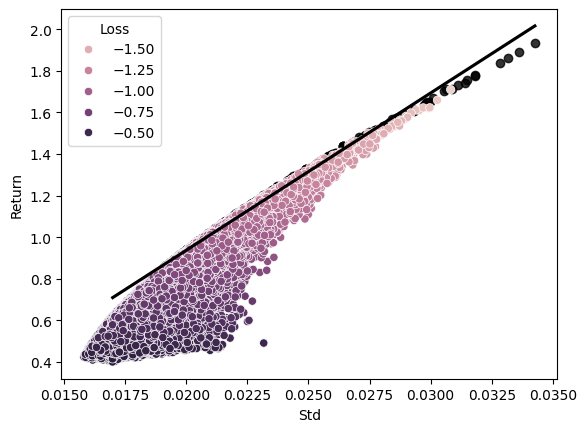

In [34]:
ax = sns.regplot(data=pf_data, y="Return", x="Std", color="black", fit_reg=True, ci=None, robust=True)
sns.scatterplot(data=df, y="Return", x="Std", hue="Loss", ax=ax)